# EDL Uncertainty Evaluation

This notebook evaluates uncertainty quantification for Wi-Fi Human Activity Recognition (Wi-HAR) using three approaches: softmax, EDL and GEN.

### Evaluation Tasks
1. **Accuracy vs. Uncertainty**: How model accuracy changes as uncertain samples are filtered out.
2. **OOD Detection (ROC/AUC)**: How well each method separates in-distribution from out-of-distribution (OOD) data.

## 1. Setup & Imports

Import libraries and define global paths, constants, and device configuration.

In [32]:
from collections.abc import Callable
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import scienceplots  # noqa: F401
import torch
from edl_losses.edl import edl_inference
from edl_losses.gen import gen_inference
from scipy.stats import beta as beta_dist
from sklearn.metrics import auc, roc_curve
from sklearn.neighbors import KernelDensity

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.job import init_rng, make_dataloader
from csi_vae.studies import get_best_model, read_studies

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300, "svg.fonttype": "none"})

settings = JobSettings()

OUT_DIR = Path("../out")
FUSION_LAUNCH_DIR = OUT_DIR / "fusion"
PLOTS_DIR = OUT_DIR / "plots"
EDL_DIR = OUT_DIR / "edl_old"
WEIGHTS_DIR = Path("../weights")
FUSION_WEIGHTS_DIR = WEIGHTS_DIR / "fusion"
EDL_WEIGHTS_DIR = WEIGHTS_DIR / "edl_old"
OOD_DATASETS = [
    Path("../") / "dataset" / f"{ds}.h5"
    for ds in ["S1b", "S1c", "S2a", "S2b", "S2c", "S4a", "S4b", "S4c", "S6a", "S6b", "S6c"]
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTIVITIES = ["Walk", "Run", "Jump", "Sit", "Empty", "Stand", "Waving", "Clap", "Lay down", "Wipe", "Squat", "Stretch"]

PLOTS_DIR.mkdir(exist_ok=True)

## 2. Load Best Wi-HAR Model

Load the best-performing fusion model found by the Optuna hyperparameter search.

In [33]:
studies = read_studies(str(FUSION_LAUNCH_DIR))
wi_har_results = get_best_model(studies)
init_rng(wi_har_results.seed)

wi_har_results

StudyResult(n_gaussians=2, trial_number=77, trial_value=0.965625, seed=347227206, best_seed_accuracy=0.98125, accuracies_per_seed={'769622246': 0.96875, '420148083': 0.9666666666666667, '1546791838': 0.9541666666666667, '1062011930': 0.9729166666666667, '347227206': 0.98125, '528409543': 0.9708333333333333, '860377586': 0.9625, '1195442376': 0.9416666666666667, '844665796': 0.9645833333333333, '528653765': 0.9583333333333334}, params={'batch_size_exp': 6, 'conv_layers_spec': 2, 'fusion_dropout': 0.0, 'kl_max': 17.84387815016845, 'lr': 0.0032226209133048383, 'n_fusion_layers': 2})

In [34]:
def make_gaussians() -> list[vae.SingleAntenna]:
    """Create a list of SingleAntenna models based on the best model's parameters.

    Returns:
        A list of SingleAntenna models, one for each antenna, initialized with the parameters from the best model.

    """
    return [
        vae.SingleAntenna(
            settings.window_size,
            settings.n_subcarriers,
            wi_har_results.n_gaussians,
            vae.CONV_SPECS[wi_har_results.params["conv_layers_spec"]],
        ).to(DEVICE)
        for _ in range(settings.n_antennas)
    ]


wi_har_gaussians = make_gaussians()
wi_har_model = fusion.Delayed(
    wi_har_gaussians,
    wi_har_results.n_gaussians,
    settings.n_activities,
    wi_har_results.params["n_fusion_layers"],
    wi_har_results.params["fusion_dropout"],
).to(DEVICE)

model_path = (
    FUSION_WEIGHTS_DIR
    / f"l{wi_har_results.n_gaussians}"
    / f"t{wi_har_results.trial_number}"
    / f"s{wi_har_results.seed}"
    / "delayed_fusion.pt"
)
wi_har_model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

## 3. Load Datasets

Load the in-distribution train/val/test splits and define a helper to load OOD datasets.

In [35]:
train_ds, val_ds, test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
full_ds = torch.utils.data.ConcatDataset([train_ds, val_ds, test_ds])

batch_size = 2 ** wi_har_results.params["batch_size_exp"]
train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=wi_har_results.seed)
val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=wi_har_results.seed)
test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=wi_har_results.seed)


def get_ood_dl(dataset_path: Path) -> torch.utils.data.DataLoader:
    """Load the OOD dataset and return a DataLoader for it."""
    _, _, ood_test_ds = dataset.load(
        dataset_path=dataset_path,
        window_size=settings.window_size,
        n_activities=settings.n_activities,
        stride=settings.stride,
    )
    return make_dataloader(ood_test_ds, batch_size=batch_size, shuffle=False, seed=wi_har_results.seed)

## 4. Load EDL and GEN Models

Load the best EDL and GEN models found by their respective Optuna studies.

In [36]:
edl_study = optuna.load_study(
    study_name="edl",
    storage=f"sqlite:///{EDL_DIR}/edl.sqlite",
)
edl_gaussians = make_gaussians()
edl_model = fusion.Delayed(
    edl_gaussians,
    wi_har_results.n_gaussians,
    settings.n_activities,
    wi_har_results.params["n_fusion_layers"],
    wi_har_results.params["fusion_dropout"],
)
edl_model.to(DEVICE)
edl_model.load_state_dict(
    torch.load(EDL_WEIGHTS_DIR / "edl" / f"t{edl_study.best_trial.number}" / "delayed_fusion.pt"),
)

<All keys matched successfully>

In [37]:
gen_study = optuna.load_study(
    study_name="gen",
    storage=f"sqlite:///{EDL_DIR}/gen.sqlite",
)
gen_gaussians = make_gaussians()
gen_model = fusion.Delayed(
    gen_gaussians,
    wi_har_results.n_gaussians,
    settings.n_activities,
    wi_har_results.params["n_fusion_layers"],
    wi_har_results.params["fusion_dropout"],
).to(DEVICE)
gen_model.load_state_dict(
    torch.load(EDL_WEIGHTS_DIR / "gen" / f"t{gen_study.best_trial.number}" / "delayed_fusion.pt"),
)

<All keys matched successfully>

## 5. Accuracy vs. Uncertainty

Evaluate how model accuracy improves as highly uncertain samples are progressively filtered out. A well-calibrated uncertainty estimate should yield higher accuracy at lower uncertainty thresholds.

In [38]:
@torch.no_grad()
def _softmax_inference(logits: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Inference function for softmax-based model."""
    logits = logits.float()
    probs = torch.nn.functional.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)
    k = logits.shape[-1]
    eps = 1e-10
    entropy = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # [0, log(K)]
    uncertainty = entropy / torch.log(torch.tensor(float(k)))  # normalized to [0, 1]

    return pred, uncertainty, probs

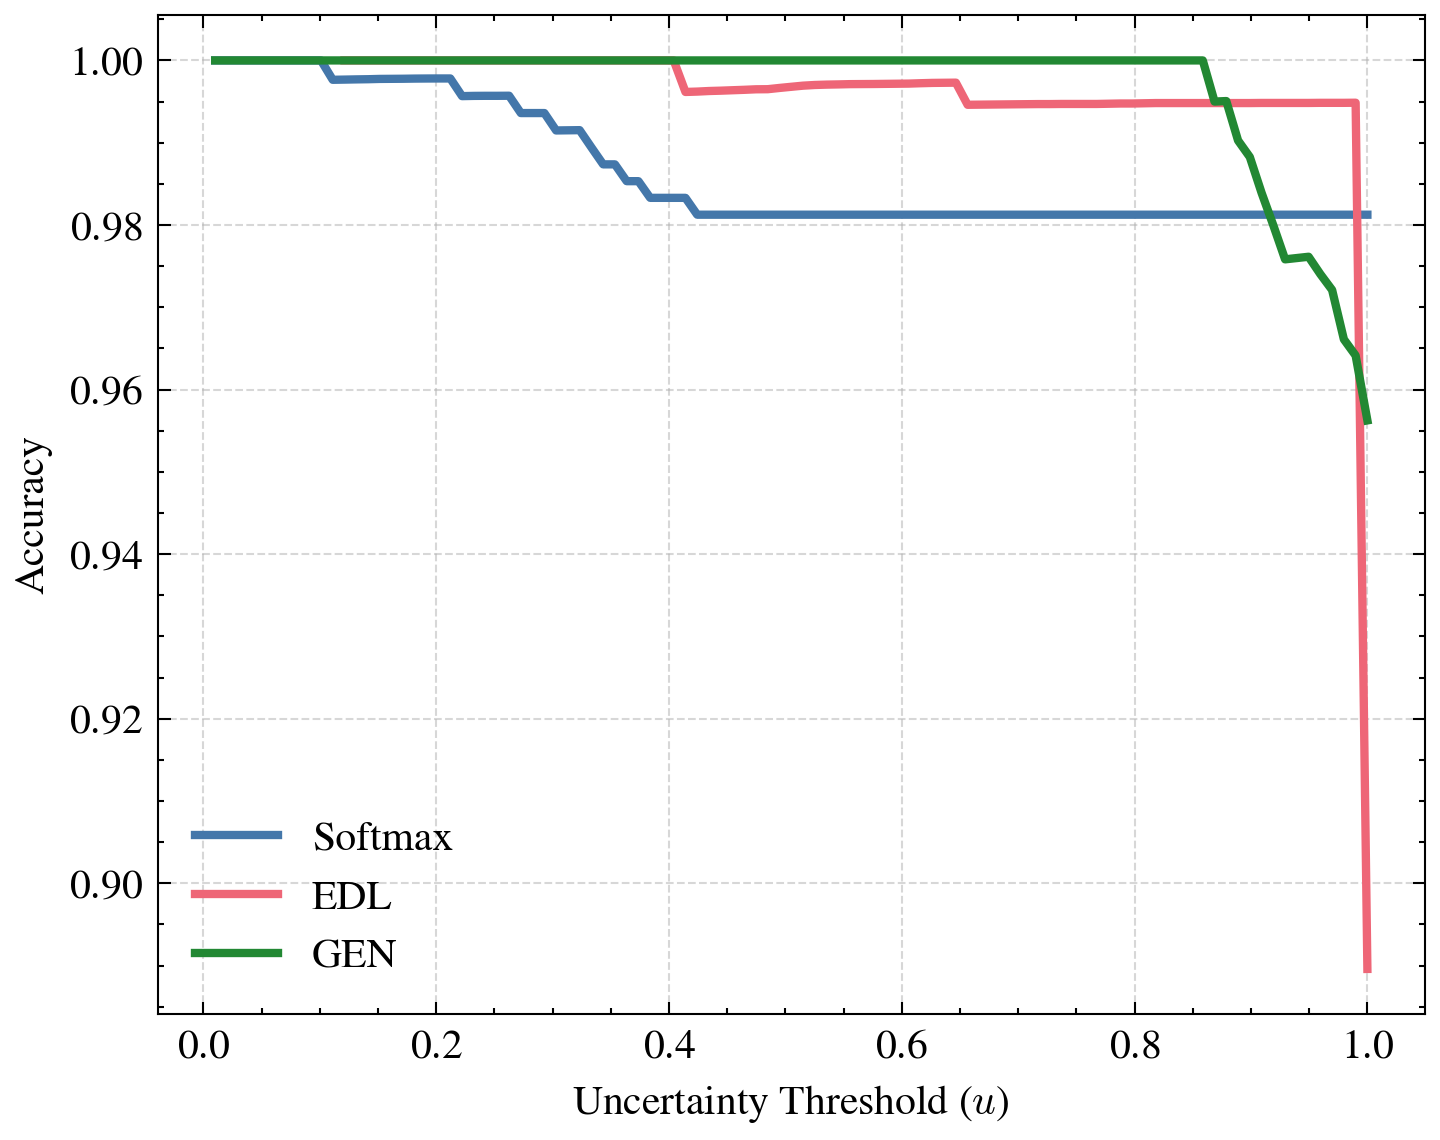

In [39]:
@torch.no_grad()
def compute_uncertainty_accuracy(
    model: torch.nn.Module,
    inference_fn: Callable,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute accuracy vs uncertainty curve for the given model and dataloader."""
    model.eval().to(device)

    all_uncertainties: list[torch.Tensor] = []
    all_correct: list[torch.Tensor] = []

    for x, y in dataloader:
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(x.to(device))

        pred, uncertainty, _ = inference_fn(logits.float())

        all_correct.append((pred == y.to(device)).detach())
        all_uncertainties.append(uncertainty.detach())

    all_correct_t = torch.cat(all_correct)
    all_uncertainties_t = torch.cat(all_uncertainties)

    thresholds = torch.linspace(0.0, 1.0, 100)
    accuracies = torch.full_like(thresholds, torch.nan, dtype=torch.float32)

    for i, t in enumerate(thresholds):
        mask = all_uncertainties_t <= t
        if mask.any():
            accuracies[i] = all_correct_t[mask].float().mean()

    return thresholds, accuracies


softmax_thresholds, softmax_accuracies = compute_uncertainty_accuracy(wi_har_model, _softmax_inference, test_dl, DEVICE)
edl_thresholds, edl_accuracies = compute_uncertainty_accuracy(edl_model, edl_inference, test_dl, DEVICE)
gen_thresholds, gen_accuracies = compute_uncertainty_accuracy(gen_model, gen_inference, test_dl, DEVICE)

plt.figure(figsize=(5, 4))

plt.plot(softmax_thresholds, softmax_accuracies, lw=2, label="Softmax")
plt.plot(edl_thresholds, edl_accuracies, lw=2, label="EDL")
plt.plot(gen_thresholds, gen_accuracies, lw=2, label="GEN")

plt.xlabel("Uncertainty Threshold ($u$)")
plt.ylabel("Accuracy")
plt.tick_params(axis="y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_thresholds.pdf")
plt.show()

## 6. OOD Detection via ROC Curve

Measure how well each model's uncertainty score separates in-distribution (ID) from out-of-distribution (OOD) samples using the AUC-ROC metric.

A sample with uncertainty exceeding what is expected on training data (modelled as a Beta distribution) is flagged as OOD.

### 6.1 Beta Distribution

In [40]:
@torch.no_grad()
def beta_interval(
    model: fusion.Delayed,
    inference_fn: Callable,
    train_dl: torch.utils.data.DataLoader,
    device: torch.device,
    interval: float = 0.95,
) -> tuple[float, float, float, float]:
    """Compute a Beta distribution credible interval for in-distribution uncertainty.

    Fits a Beta distribution to the uncertainty scores on the training set, then
    returns the interval bounds at the requested confidence level along with the
    fitted shape parameters.

    Arguments:
        model: The trained fusion.Delayed model to evaluate.
        inference_fn: A function that takes the model's logits and returns
            (predictions, uncertainties, probabilities).
        train_dl: DataLoader for the training dataset used to fit the Beta distribution.
        device: Device to run inference on.
        interval: Confidence level for the credible interval (default: 0.95).

    Returns:
        A tuple (lower, upper, alpha, beta) where lower/upper are the interval
        bounds and alpha/beta are the fitted Beta distribution shape parameters.

    """
    model.eval().to(DEVICE)
    all_correct = []
    all_uncertainties = []

    for x, y in train_dl:
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(x.to(device, non_blocking=True))
        pred, uncertainty, _ = inference_fn(logits.float())

        mask_correct = pred == y.to(device, non_blocking=True)
        all_correct.append(mask_correct)
        all_uncertainties.append(uncertainty)

    correct = torch.cat(all_correct)
    uncertainties = torch.cat(all_uncertainties)[correct]
    uncertainties = uncertainties.cpu().numpy().clip(1e-6, 1 - 1e-6)

    a, b, _, _ = beta_dist.fit(uncertainties, floc=0, fscale=1)
    lower, upper = beta_dist.interval(interval, a, b)
    return lower, upper, float(a), float(b)  # pyright: ignore[reportArgumentType]

In [41]:
models = [
    ("Softmax", wi_har_model, _softmax_inference),
    ("EDL", edl_model, edl_inference),
    ("GEN", gen_model, gen_inference),
]

for (model_name, model, inference_fn) in models:
    lower, upper, a, b = beta_interval(model, inference_fn, train_dl, DEVICE)
    print(f"{model_name} Beta Interval: [{lower:.4f}, {upper:.4f}] with a={a:.2f}, b={b:.2f}")

Softmax Beta Interval: [0.0000, 0.1124] with a=0.22, b=13.70
EDL Beta Interval: [0.0040, 0.9990] with a=0.57, b=0.48
GEN Beta Interval: [0.0001, 0.9486] with a=0.41, b=0.96


### 6.2 KDE

In [42]:
@torch.no_grad()
def kde_fit(
    model: fusion.Delayed,
    inference_fn: Callable,
    train_dl: torch.utils.data.DataLoader,
    device: torch.device,
    interval: float = 0.95,
) -> tuple[KernelDensity, float]:
    """Fit a KDE on training uncertainty scores and return the KDE and the threshold.

    The KDE is used to score test samples: the negative log-density under the
    in-distribution KDE is used as the OOD score (low density = more OOD).
    The threshold corresponds to the `interval`-th percentile of training
    uncertainties, giving a single operating point on the ROC.

    Arguments:
        model: The trained fusion.Delayed model to evaluate.
        inference_fn: A function that takes the model's logits and returns
            (predictions, uncertainties, probabilities).
        train_dl: DataLoader for the training dataset used to fit the KDE.
        device: Device to run inference on.
        interval: Confidence level for the operating-point threshold (default: 0.95).

    Returns:
        A tuple (kde, threshold) where kde is the fitted KernelDensity and
        threshold is the empirical percentile at the given confidence level.

    """
    model.eval()
    all_correct = []
    all_uncertainties = []

    for x, y in train_dl:
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(x.to(device, non_blocking=True))
        pred, uncertainty, _ = inference_fn(logits.float())
        mask_correct = pred == y.to(device, non_blocking=True)
        all_correct.append(mask_correct)
        all_uncertainties.append(uncertainty)

    correct = torch.cat(all_correct)
    uncertainties = torch.cat(all_uncertainties)[correct].cpu().numpy()

    kde = KernelDensity(kernel="gaussian", bandwidth="scott").fit(uncertainties[:, None])
    threshold = float(np.percentile(uncertainties, interval * 100))
    return kde, threshold

### 6.3 Plots

In [43]:
@torch.no_grad()
def _collect_uncertainties(
    model: torch.nn.Module,
    inference_fn: Callable,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> np.ndarray:
    """Collect uncertainty scores for all samples in a dataloader.

    Arguments:
        model: The trained model to evaluate.
        inference_fn: A function that takes the model's logits and returns
            (predictions, uncertainties, probabilities).
        dataloader: DataLoader for the dataset to collect uncertainties from.
        device: Device to run inference on.

    Returns:
        A NumPy array of uncertainty scores for all samples in the dataloader.

    """
    all_uncertainties: list[torch.Tensor] = []

    for x, _ in dataloader:
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(x.to(device, non_blocking=True))
        _, uncertainty, _ = inference_fn(logits.float())
        all_uncertainties.append(uncertainty)

    return torch.cat(all_uncertainties).cpu().numpy()


def compute_ood_roc(
    model: fusion.Delayed,
    inference_fn: Callable,
    kde: KernelDensity,
    id_dl: torch.utils.data.DataLoader,
    ood_dl: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Compute OOD detection ROC data for each model and OOD dataset.

    Arguments:
        model: The trained fusion.Delayed model to evaluate.
        inference_fn: A function that takes the model's logits and returns
            (predictions, uncertainties, probabilities).
        kde: The fitted KernelDensity object.
        id_dl: DataLoader for the in-distribution test set.
        ood_dl: DataLoader for the OOD dataset to evaluate.
        device: Device to run inference on.

    Returns:
        tuple[np.ndarray, np.ndarray, float]: A tuple containing the false positive rates,
        true positive rates, and AUC for the OOD detection task.

    """
    model.eval()

    # Collect ID uncertainties — single CPU transfer
    id_uncertainties = _collect_uncertainties(model, inference_fn, id_dl, device)
    id_scores = -kde.score_samples(id_uncertainties[:, None])

    # Collect OOD uncertainties — single CPU transfer
    ood_uncertainties = _collect_uncertainties(model, inference_fn, ood_dl, device)
    ood_scores = -kde.score_samples(ood_uncertainties[:, None])

    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([
        np.zeros(len(id_scores)),  # 0 = ID
        np.ones(len(ood_scores)),  # 1 = OOD
    ])

    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, float(roc_auc)

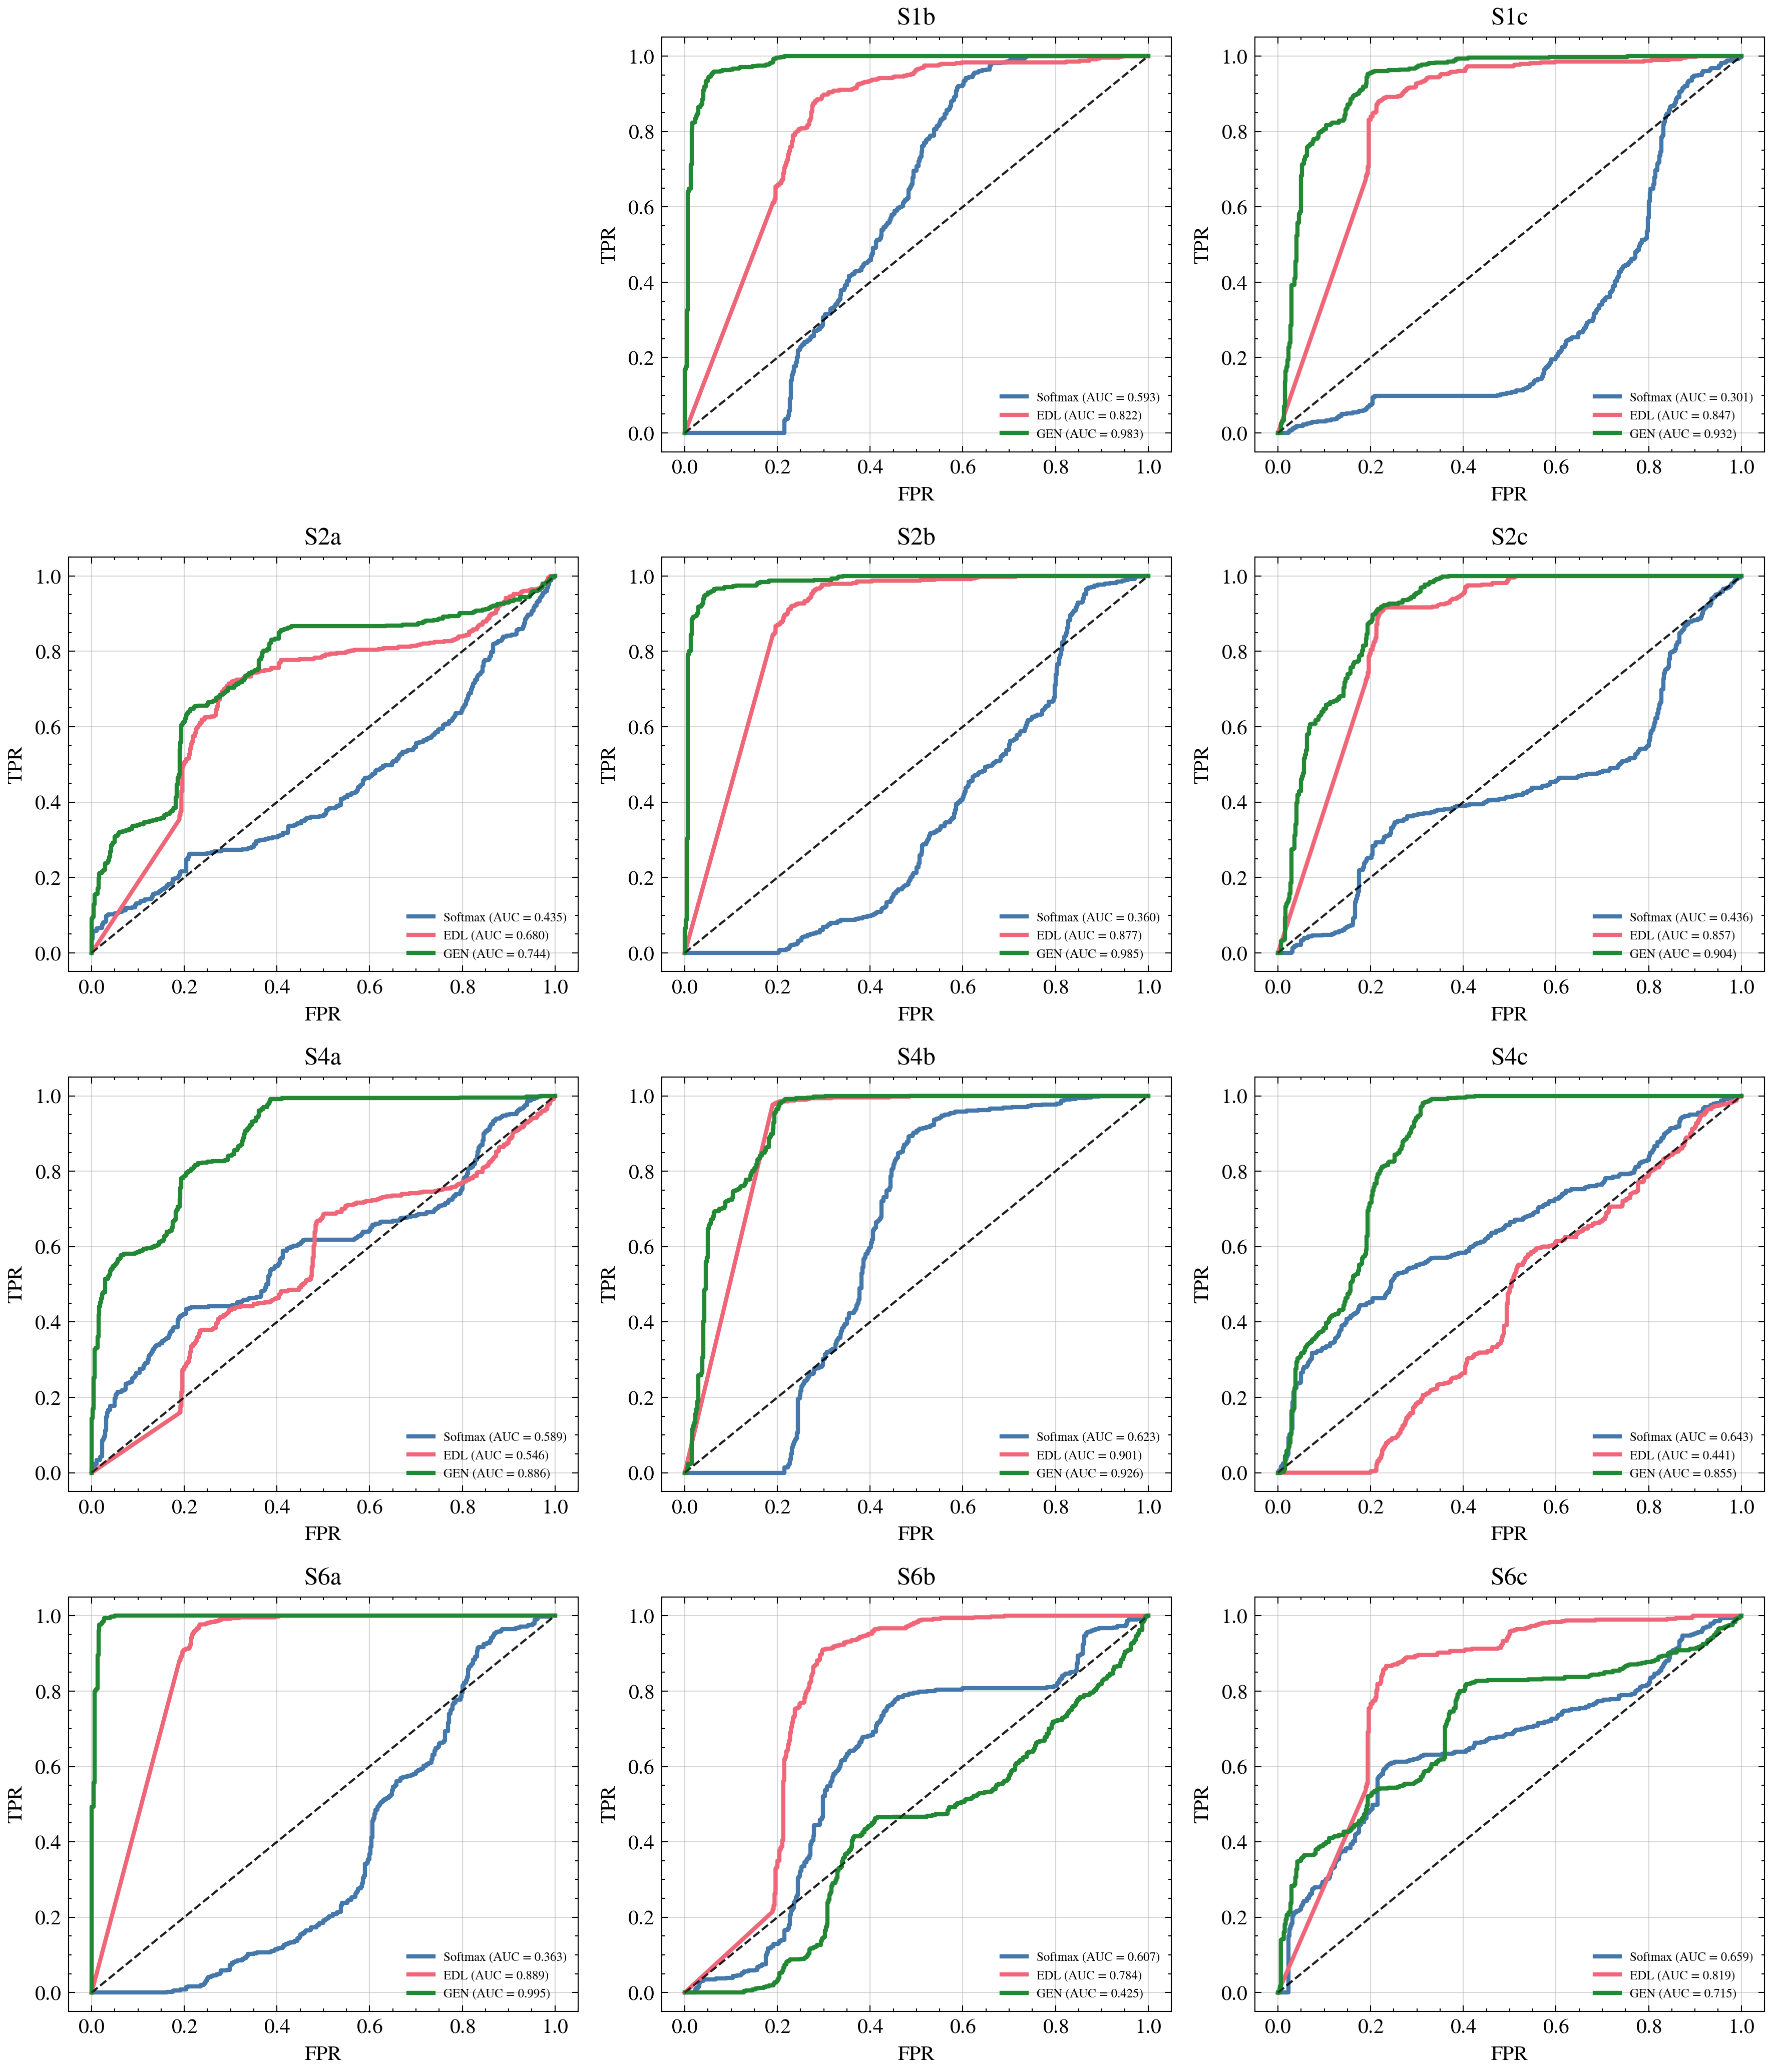

In [44]:
models = [
    ("Softmax", wi_har_model, _softmax_inference),
    ("EDL", edl_model, edl_inference),
    ("GEN", gen_model, gen_inference),
]

n = len(OOD_DATASETS)
ncols = 3
nrows = (n + ncols - 1) // ncols

_, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

ood_datasets = [(ds.stem, get_ood_dl(ds)) for ds in OOD_DATASETS]

for model_name, model, inference_fn in models:
    kde, _ = kde_fit(model, inference_fn, train_dl, DEVICE)

    for idx, ood_dataset in enumerate(ood_datasets, start=1):
        ood_name = ood_dataset[0]
        ax = axes[idx]
        fpr, tpr, roc_auc = compute_ood_roc(model, inference_fn, kde, test_dl, ood_dataset[1], DEVICE)

        ax.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.3f})")
        ax.plot([0, 1], [0, 1], color="k", linestyle="--", alpha=0.5)
        ax.set_title(ood_name)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right", fontsize=6)
        ax.grid(True, alpha=0.5)

axes[0].set_visible(False)  # Hide the first subplot (no dataset)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_roc_grid.pdf")
plt.show()